In [1]:
pip install opencv-python 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


(-0.5, 799.5, 532.5, -0.5)

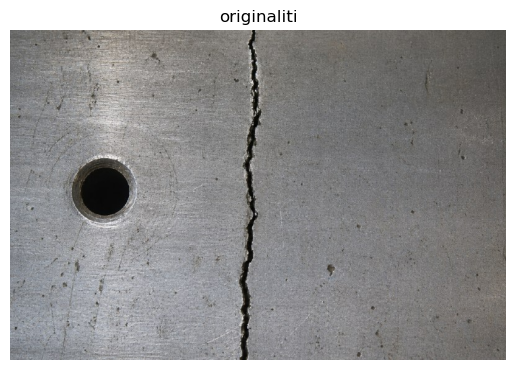

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузи изображение (замени путь на свой)
img = cv2.imread('foto.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("originaliti")
plt.axis('off')

(-0.5, 399.5, 265.5, -0.5)

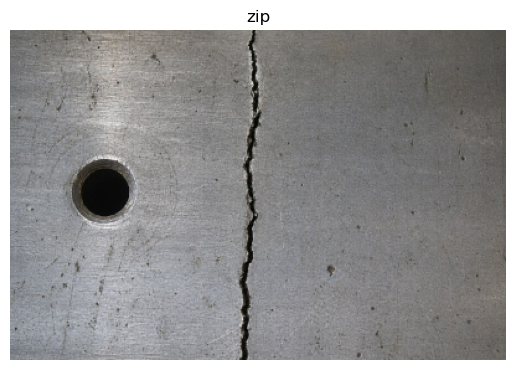

In [5]:
# уменьшаем размер (сжатие)
img_small = cv2.resize(img, (0, 0), fx=0.5, fy=0.5)

plt.imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
plt.title("zip")
plt.axis('off')

(-0.5, 399.5, 265.5, -0.5)

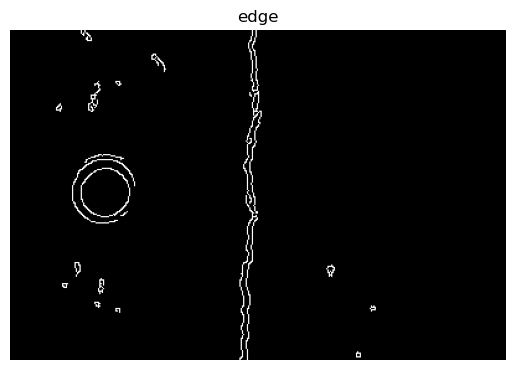

In [6]:
# Перевод в серый
gray = cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY)

# Размытие для подавления шума
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Детектор границ
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("edge")
plt.axis('off')

(-0.5, 399.5, 265.5, -0.5)

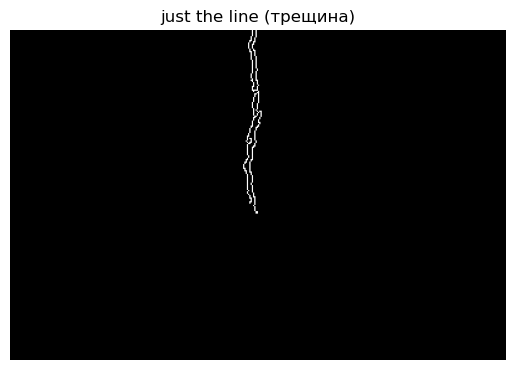

In [7]:
# Поиск контуров
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros_like(gray)

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    # Пропускаем маленькие шумы
    if area < 50:
        continue
    
    # Аппроксимация формы
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * (area / (perimeter * perimeter + 1e-5))
    
    # Удаляем круглые объекты (дырку)
    if circularity > 0.5:
        continue
    
    # Оставляем вытянутые (трещину)
    cv2.drawContours(mask, [cnt], -1, 255, thickness=1)

plt.imshow(mask, cmap='gray')
plt.title("just the line (трещина)")
plt.axis('off')

(-0.5, 399.5, 265.5, -0.5)

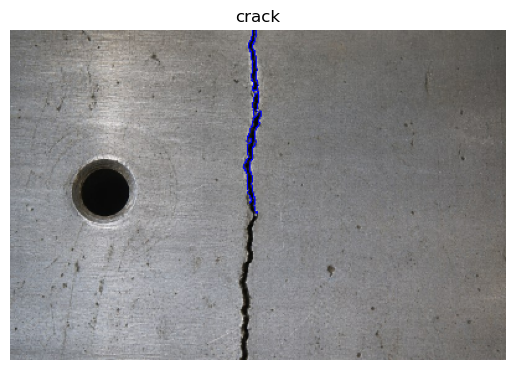

In [8]:
result = img_small.copy()
result[mask == 255] = [255, 0, 0]  # красная линия

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("crack")
plt.axis('off')

In [9]:
pip install opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.

(-0.5, 399.5, 265.5, -0.5)

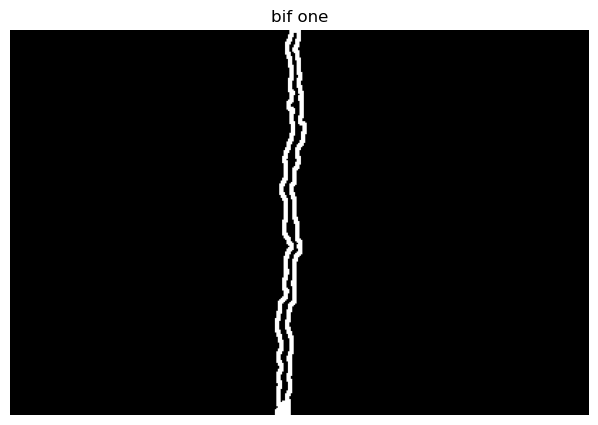

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('foto.jpg')
img = cv2.resize(img, (0,0), fx=0.5, fy=0.5)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

# чуть соединяем разрывы (но аккуратно!)
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# ищем контуры
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

best_contour = None
max_length = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100:
        continue
    
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter**2 + 1e-5)
    
    # убираем круг (дырку)
    if circularity > 0.6:
        continue
    
    # берём САМЫЙ ДЛИННЫЙ контур
    if perimeter > max_length:
        max_length = perimeter
        best_contour = cnt

# создаём маску только для одной трещины
mask = np.zeros_like(gray)

if best_contour is not None:
    cv2.drawContours(mask, [best_contour], -1, 255, 2)

# результат
plt.figure(figsize=(10,5))
plt.imshow(mask, cmap='gray')
plt.title("bif one")
plt.axis('off')